# 3 — Analysis and geospatial visualisation

**Inputs:**

| File | Contents |
|---|---|
| `data/raw/trips_clean.parquet` | Cleaned citywide trip records, 56,637,949 rows. Used for every distribution, outlier, and geospatial result. |
| `data/curated/model_table.parquet` | The airport-hour table, 26,256 rows × 79 columns. Used for the target, temporal, flight, and weather results. |
| `data/curated/shapes_taxi.json` | Preprocessing shapes, used here to verify that this notebook is reading what 2a wrote. |
| `data/landing/tlc/taxi_zone_lookup.csv`, `data/landing/tlc/taxi_zones/` | Zone names, boroughs, and the zone shapefile. |

**Outputs:** seven figures in `plots/`, plus `data/curated/distribution_summary.csv` and
`data/curated/analysis_findings.json` — the numbers the report quotes, written as data so
that a figure in the prose and the code that produced it cannot drift apart.

## What this notebook is for, and the one framing constraint

Pickups happen in exactly two zones, so a map of pickup locations would be two coloured
polygons and no information. The geospatial question worth asking is where the money
**goes**: the drop-off distribution an airport queue produces. That is what makes the
recommendations concrete, because a Midtown drop-off can re-hail within minutes while a
deep-Brooklyn drop-off deadheads back to Queens, and the two are worth very different
amounts per hour of a driver's shift even when the fare on the meter is identical.

The sections below run in the order the argument needs:

1. Distributions and outliers, on the full cleaned data, airport against citywide.
2. The distribution of the modelling target, and whether a Poisson assumption survives it.
3. Temporal structure — do volume and value peak in the same hours?
4. Flights to pickups: the conversion rate, and the lag at which arrivals predict pickups.
5. Weather, matched on hour of day so that the hour-of-day confound cannot manufacture an
   effect.
6. Geospatial: where airport trips end, by airport and by time of day.
7. What carries into the modelling notebook.

## Sampling policy

**No result in this notebook is computed on a sample.** Every distribution, percentile,
outlier count, and aggregate is computed in Spark over the full 56.6M-row cleaned dataset
or the full 26,256-row airport-hour table.

Sampling appears in exactly one place: the scatter plot in Figure 1(b), which cannot render
4.65M markers legibly. It draws a 1% sample with a fixed seed, both stated in the code and
in the figure caption. Nothing is inferred from that sample that is not also computed on the
full data elsewhere in the section.

In [1]:
"""Analysis and geospatial visualisation of the airport pickup market.

Reads the cleaned citywide trip records and the joined airport-hour model
table, and produces the distribution, outlier, temporal, flight, weather, and
geospatial results the report's analysis section is built from.

Figures are written to `plots/` through `scripts/plot_utils.py`, so that one
palette, one font size, and one figure width apply across the report. Headline
numbers are written to `data/curated/analysis_findings.json` so that the report
quotes computed values rather than transcribed ones.
"""

import json
import sys
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm, Normalize, TwoSlopeNorm
from pyspark.sql import functions as F
from scipy import stats

sys.path.append(str(Path("..") / "scripts"))
from plot_utils import (  # noqa: E402
    BASELINE_COLOUR,
    DIVERGING_CMAP,
    MISSING_COLOUR,
    PALETTE,
    SEQUENTIAL_CMAP,
    airport_colour,
    currency_axis,
    heatmap,
    new_figure,
    save_figure,
    set_plot_style,
)
from spark_utils import (  # noqa: E402
    ARRIVAL_AIRPORTS,
    JFK_ZONE,
    LGA_ZONE,
    create_spark_session,
)

# --- Paths -----------------------------------------------------------------
# Notebook is expected to run from `notebooks/`.
PROJECT_ROOT = Path("..").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
CURATED_DIR = PROJECT_ROOT / "data" / "curated"
LANDING_TLC_DIR = PROJECT_ROOT / "data" / "landing" / "tlc"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Study window ----------------------------------------------------------
# Identical to notebooks 2a, 2b, and 2c.
WINDOW_START = "2023-01-01"
WINDOW_END = "2024-07-01"
WINDOW_DAYS = 547
WINDOW_HOURS = WINDOW_DAYS * 24                          # 13,128 per site
EXPECTED_ROWS = WINDOW_HOURS * len(ARRIVAL_AIRPORTS)     # 26,256

# --- Codes from the data dictionary ----------------------------------------
AIRPORT_ZONES = {JFK_ZONE: "JFK", LGA_ZONE: "LGA"}
UNKNOWN_ZONES = [264, 265]        # "Unknown" and "Outside of NYC / N.A."
PAYMENT_CARD = 1
RATECODE_JFK_FLAT = 2
RATECODE_NAMES = {
    1: "Standard rate",
    2: "JFK flat fare",
    3: "Newark",
    4: "Nassau or Westchester",
    5: "Negotiated fare",
    6: "Group ride",
    99: "Unknown",
}

# Published JFK–Manhattan flat fare in force across the whole study window,
# raised from $52.00 in the December 2022 fare revision. The figure is not
# hardcoded into any result: Step 1c derives the modal airport fare from the
# data and reports it against this constant, so a disagreement is visible
# rather than silent. Cite the TLC passenger fare page where it appears in the
# report.
JFK_FLAT_FARE = 70.00

# --- Sampling policy -------------------------------------------------------
# Used only for the scatter plot in Figure 1(b). Both values are quoted in the
# figure caption; every other result in this notebook is computed on the full
# distribution.
SAMPLE_FRACTION = 0.01
SAMPLE_SEED = 42

# --- Night, for the geospatial split ---------------------------------------
# 22:00 to 05:59 inclusive. Chosen to match the period Section 2 identifies as
# the low-demand block rather than to a generic definition of night.
NIGHT_START_HOUR = 22
NIGHT_END_HOUR = 6

set_plot_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
spark = create_spark_session(app_name="MAST30034 — analysis")
spark.sparkContext.setLogLevel("WARN")
spark.version

your 131072x1 screen size is bogus. expect trouble
26/08/17 01:40:28 WARN Utils: Your hostname, iphone resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/08/17 01:40:28 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/17 01:40:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


'3.5.1'

## Step 1 — Distributions and outliers, on the full data

The cleaned citywide table is read as written by 2a. Cleaning was applied **before** the
airport subset was taken precisely so that this step can compare the two: airport trips are
not a random sample of New York taxi trips, and the way they differ is the first evidence
that the research question is worth asking.

The airport row count is asserted against `shapes_taxi.json` rather than assumed. If a
partition failed to write, or the notebook is pointed at a different study window, this is
where it should fail — not thirty cells later in a percentile that looks plausible.

Note on cost: this notebook makes roughly eight passes over the 56.6M-row table. Every one
is column-pruned and none collects more than a few hundred rows to the driver, so the
memory profile is flat; the time is disk-bound.

In [3]:
trips = (
    spark.read.parquet(str(RAW_DIR / "trips_clean.parquet"))
    .withColumn("is_airport", F.col("pulocationid").isin(list(AIRPORT_ZONES)))
)

with open(CURATED_DIR / "shapes_taxi.json") as handle:
    shapes_taxi = json.load(handle)

clean_total = trips.count()
airport_total = trips.where(F.col("is_airport")).count()

assert clean_total == shapes_taxi["cleaned_citywide_trips"], (
    f"{clean_total:,} rows on disk, 2a wrote "
    f"{shapes_taxi['cleaned_citywide_trips']:,}"
)
assert airport_total == shapes_taxi["airport_pickups"], (
    f"{airport_total:,} airport pickups, 2a wrote "
    f"{shapes_taxi['airport_pickups']:,}"
)

print(f"Cleaned citywide trips  {clean_total:,}")
print(f"Airport pickups         {airport_total:,} "
      f"({100 * airport_total / clean_total:.2f}% of cleaned trips)")

Cleaned citywide trips  56,637,949
Airport pickups         4,653,181 (8.22% of cleaned trips)


### Step 1a — One pass, four segments

Four segments are described: citywide, the two airports together, and each airport alone.
Computing them as four filtered frames would mean four scans of 56.6M rows. Instead each
segment is a **mask** — `F.when(predicate, value)` — and all four are aggregated in a single
pass. `F.count` of a masked column counts its non-null values, so each statistic is taken
over its own segment without the frame ever being filtered.

`tip_ratio` carries a second restriction inside the mask. The data dictionary states that
the tip field is populated for card payments only, so a tip statistic computed over all
trips would be measuring the payment mix rather than tipping behaviour. This is the same
denominator rule 2a applied when aggregating `mean_tip_ratio`, restated here so the two
agree.

The 99.9th percentile is reported alongside the usual five. At 56.6M rows the 99th
percentile still has 566,000 trips above it, so it is nowhere near the tail that the outlier
discussion is about.

In [4]:
PERCENTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]
PERCENTILE_LABELS = ["p1", "p5", "p25", "p50", "p75", "p95", "p99", "p99_9"]

# Relative error of the sketch, at one part in a thousand. The Spark default of
# 10,000 is finer than anything reported here and there are twenty sketches in
# the single pass below.
PERCENTILE_ACCURACY = 1000

# Segments, as masks rather than as filtered frames.
SEGMENTS = {
    "citywide": F.lit(True),
    "airport": F.col("is_airport"),
    "JFK": F.col("pulocationid") == JFK_ZONE,
    "LGA": F.col("pulocationid") == LGA_ZONE,
}

# Metrics. Duration is converted to minutes here rather than reported in
# seconds, so that every figure and table in the report uses one unit.
METRICS = {
    "fare_amount": F.col("fare_amount"),
    "total_amount": F.col("total_amount"),
    "trip_distance_mi": F.col("trip_distance"),
    "duration_min": F.col("trip_duration_s") / 60.0,
    "tip_ratio": F.when(
        F.col("payment_type") == PAYMENT_CARD,
        F.col("tip_amount") / F.col("fare_amount"),
    ),
}


def distribution_expressions(segment: str, predicate, metric: str, value) -> list:
    """Aggregate expressions describing one metric within one segment.

    Args:
        segment: Segment name, used to prefix the output column names.
        predicate: Boolean Column selecting the segment's rows.
        metric: Metric name, used in the output column names.
        value: Column holding the metric. May itself be conditional, in which
            case the two conditions compose and the statistic is taken over
            their intersection.

    Returns:
        List of aggregate Columns, named ``segment|metric|statistic``.
    """
    masked = F.when(predicate, value)
    prefix = f"{segment}|{metric}"
    return [
        F.count(masked).alias(f"{prefix}|n"),
        F.avg(masked).alias(f"{prefix}|mean"),
        F.stddev(masked).alias(f"{prefix}|sd"),
        F.skewness(masked).alias(f"{prefix}|skew"),
        F.percentile_approx(masked, PERCENTILES, PERCENTILE_ACCURACY)
        .alias(f"{prefix}|pct"),
    ]

In [5]:
expressions = [
    expression
    for segment, predicate in SEGMENTS.items()
    for metric, value in METRICS.items()
    for expression in distribution_expressions(segment, predicate, metric, value)
]

# One pass over all 56,637,949 cleaned trips. No sampling.
summary_row = trips.agg(*expressions).collect()[0].asDict()

records = []
for segment in SEGMENTS:
    for metric in METRICS:
        prefix = f"{segment}|{metric}"
        record = {
            "segment": segment,
            "metric": metric,
            "n": summary_row[f"{prefix}|n"],
            "mean": summary_row[f"{prefix}|mean"],
            "sd": summary_row[f"{prefix}|sd"],
            "skew": summary_row[f"{prefix}|skew"],
        }
        record.update(dict(zip(PERCENTILE_LABELS, summary_row[f"{prefix}|pct"])))
        records.append(record)

distributions = pd.DataFrame(records)
distributions.to_csv(CURATED_DIR / "distribution_summary.csv", index=False)
print(f"Written to {CURATED_DIR / 'distribution_summary.csv'}")

distributions.round(3)

26/08/17 01:40:40 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Written to /home/tavish/projects/project-1-individual-SavvyHack/data/curated/distribution_summary.csv


,segment,metric,n,mean,sd,skew,p1,p5,p25,p50,p75,p95,p99,p99_9
0,citywide,fare_amount,56637949,19.603,62.754,4820.351,4.400,5.800,9.300,13.500,21.900,65.300,73.700,386983.630
1,citywide,total_amount,56637949,28.625,64.215,4498.509,9.400,11.750,16.000,21.000,30.600,82.290,103.340,386987.630
2,citywide,trip_distance_mi,56637949,3.476,4.500,3.175,0.310,0.550,1.100,1.810,3.440,15.040,20.050,334.090
3,citywide,duration_min,56637949,16.477,13.335,2.654,2.233,3.800,7.817,12.750,20.633,42.633,66.400,360.000
4,citywide,tip_ratio,44485655,0.255,8.769,2060.228,0.000,0.012,0.201,0.259,0.306,0.402,0.523,27500.000
5,airport,fare_amount,4653181,55.684,24.389,3.877,12.800,21.900,40.100,55.500,70.000,79.300,131.800,1916.800
6,airport,total_amount,4653181,76.078,28.821,2.772,18.850,30.050,60.700,77.040,92.690,105.060,161.850,1939.550
7,airport,trip_distance_mi,4653181,13.552,6.094,1.590,2.100,4.600,9.150,12.360,18.000,21.580,29.000,281.760
8,airport,duration_min,4653181,37.783,18.618,1.345,6.317,12.617,24.417,35.483,48.317,70.700,89.967,360.000
9,airport,tip_ratio,3627513,0.233,18.318,992.613,0.000,0.000,0.171,0.231,0.268,0.332,0.408,21000.000


### Step 1b — Outliers: Tukey fences on the full distribution

An outlier here is a record that is **extreme**, not one that is invalid: everything invalid
was removed in 2a against a documented business rule, and everything merely extreme was
deliberately retained so that this step could describe it rather than inherit a distribution
already quietly narrowed.

Tukey's fence, `p75 + 1.5 × IQR`, is used because it is a function of the quartiles rather
than of the mean and standard deviation, and every metric here is heavily right-skewed —
the skewness column above says so — which is exactly the case where a mean-and-sigma rule
misbehaves.

Only the **upper** fence is counted. Each metric is bounded below by a filter 2a already
enforced: fare and total are positive, distance is positive, duration is at least a minute.
Nothing can lie below the lower fence, and reporting a count of zero four times would be
noise.

In [6]:
TUKEY_MULTIPLIER = 1.5

fences = distributions.assign(
    iqr=lambda frame: frame["p75"] - frame["p25"],
)
fences["upper_fence"] = fences["p75"] + TUKEY_MULTIPLIER * fences["iqr"]

# Count what lies beyond each fence — again in one pass, again on the full data.
exceedance_expressions = [
    F.sum(
        F.when(
            SEGMENTS[row.segment] & (METRICS[row.metric] > row.upper_fence), 1
        ).otherwise(0)
    ).alias(f"{row.segment}|{row.metric}")
    for row in fences.itertuples()
]
exceedance_row = trips.agg(*exceedance_expressions).collect()[0].asDict()

fences["n_above_fence"] = [
    exceedance_row[f"{row.segment}|{row.metric}"] for row in fences.itertuples()
]
fences["pct_above_fence"] = 100 * fences["n_above_fence"] / fences["n"]

fences[[
    "segment", "metric", "p25", "p50", "p75", "upper_fence", "p99_9",
    "n_above_fence", "pct_above_fence",
]].round(3)

,segment,metric,p25,p50,p75,upper_fence,p99_9,n_above_fence,pct_above_fence
0,citywide,fare_amount,9.300,13.500,21.900,40.800,386983.630,5612865,9.910
1,citywide,total_amount,16.000,21.000,30.600,52.500,386987.630,6340470,11.195
2,citywide,trip_distance_mi,1.100,1.810,3.440,6.950,334.090,7434123,13.126
3,citywide,duration_min,7.817,12.750,20.633,39.858,360.000,3400212,6.003
4,citywide,tip_ratio,0.201,0.259,0.306,0.462,27500.000,934588,2.101
5,airport,fare_amount,40.100,55.500,70.000,114.850,1916.800,66018,1.419
6,airport,total_amount,60.700,77.040,92.690,140.675,1939.550,67029,1.440
7,airport,trip_distance_mi,9.150,12.360,18.000,31.275,281.760,34889,0.750
8,airport,duration_min,24.417,35.483,48.317,84.167,360.000,76988,1.655
9,airport,tip_ratio,0.171,0.231,0.268,0.413,21000.000,34948,0.963


### Step 1c — What the extreme trips actually are

A count of outliers is not an outlier analysis. The question the report has to answer is
whether the extreme tail is corruption that survived the filters or real journeys that the
model must accommodate, and the way to answer it is to name them.

Airport trips beyond the fare fence are profiled by **rate code** and **drop-off borough**.
Rate code is the informative dimension because it is entered at the meter and describes the
fare *regime*: code 4 is the Nassau or Westchester out-of-city rate, code 5 is a negotiated
fare, code 3 is Newark. A long tail composed of those codes is a tail of genuine long-haul
runs. A long tail on the standard rate with no distance to justify it would be something
else entirely.

In [7]:
zone_lookup = pd.read_csv(LANDING_TLC_DIR / "taxi_zone_lookup.csv").rename(
    columns={
        "LocationID": "locationid",
        "Borough": "borough",
        "Zone": "zone",
        "service_zone": "service_zone",
    }
)

# The lookup is 265 rows and is joined to a multi-million-row frame, so it is
# broadcast rather than shuffled.
dropoff_zones = (
    spark.createDataFrame(zone_lookup[["locationid", "borough", "zone"]])
    .withColumnRenamed("locationid", "dolocationid")
    .withColumnRenamed("borough", "dropoff_borough")
    .withColumnRenamed("zone", "dropoff_zone")
)

airport_fare_fence = float(
    fences.loc[
        (fences["segment"] == "airport") & (fences["metric"] == "fare_amount"),
        "upper_fence",
    ].iloc[0]
)

extremes = (
    trips
    .where(F.col("is_airport") & (F.col("fare_amount") > airport_fare_fence))
    .join(F.broadcast(dropoff_zones), "dolocationid", "left")
    .groupBy("ratecodeid", "dropoff_borough")
    .agg(
        F.count("*").alias("trips"),
        F.avg("fare_amount").alias("mean_fare"),
        F.avg("trip_distance").alias("mean_distance_mi"),
        F.avg(F.col("trip_duration_s") / 60.0).alias("mean_duration_min"),
    )
    .toPandas()
)

# `ratecodeid` is nullable and therefore arrives as a float, so an int-keyed
# lookup would silently match nothing.
extremes["rate_code"] = (
    extremes["ratecodeid"]
    .map(lambda value: RATECODE_NAMES.get(int(value)) if pd.notna(value) else None)
    .fillna("Unrecorded")
)
extremes["pct_of_extremes"] = 100 * extremes["trips"] / extremes["trips"].sum()

extreme_total = int(extremes["trips"].sum())
extreme_pct = 100 * extreme_total / airport_total
print(f"Airport trips above the ${airport_fare_fence:,.2f} fare fence: "
      f"{extreme_total:,} ({extreme_pct:.2f}% of airport pickups)")

extremes.nlargest(10, "trips")[[
    "rate_code", "dropoff_borough", "trips", "pct_of_extremes",
    "mean_fare", "mean_distance_mi", "mean_duration_min",
]].round(2).reset_index(drop=True)

Airport trips above the $114.85 fare fence: 66,018 (1.42% of airport pickups)


,rate_code,dropoff_borough,trips,pct_of_extremes,mean_fare,mean_distance_mi,mean_duration_min
0,Nassau or Westchester,None,33634,50.95,179.46,32.51,57.31
1,Negotiated fare,None,14698,22.26,182.57,34.75,68.31
2,Newark,EWR,4963,7.52,151.85,34.95,68.38
3,Standard rate,None,2963,4.49,154.43,40.38,75.57
4,Newark,None,2736,4.14,157.67,36.03,73.24
5,Standard rate,Staten Island,919,1.39,128.64,33.62,70.53
6,Standard rate,Brooklyn,913,1.38,124.61,28.43,88.14
7,Standard rate,Manhattan,749,1.13,129.89,28.24,98.94
8,Nassau or Westchester,EWR,638,0.97,176.40,35.17,67.18
9,Standard rate,Bronx,613,0.93,124.83,30.03,82.34


### Step 1d — The flat fare, and why the airport fare distribution has a spike

The single most consequential difference between the airport and citywide fare
distributions is not a shift in location — it is a **mass point**. Rate Code 2 prices any
JFK-to-Manhattan trip at one flat amount regardless of distance or traffic, so a large
share of JFK pickups bill exactly the same number of dollars.

The modal fare is derived from the data rather than assumed: every distinct fare value is
counted, in one pass, and the largest is reported against the published flat fare held in
`JFK_FLAT_FARE`. This matters for the modelling notebook as much as for the report, because
a response variable with an atom at a single value is not well described by a model that
assumes a continuous density, and because the flat fare mechanically decouples revenue from
distance for a large block of trips.

In [8]:
fare_spectrum = (
    trips
    .select(
        F.round("fare_amount", 2).alias("fare"),
        F.col("is_airport"),
        F.col("pulocationid"),
    )
    .groupBy("fare")
    .agg(
        F.count("*").alias("trips"),
        F.sum(F.col("is_airport").cast("int")).alias("airport_trips"),
        F.sum(F.when(F.col("pulocationid") == JFK_ZONE, 1).otherwise(0))
        .alias("jfk_trips"),
    )
    .toPandas()
    .sort_values("fare")
    .reset_index(drop=True)
)
print(f"{len(fare_spectrum):,} distinct metered fare values across "
      f"{clean_total:,} trips")

modal = fare_spectrum.nlargest(6, "jfk_trips").copy()
modal["pct_of_jfk"] = 100 * modal["jfk_trips"] / shapes_taxi["airport_pickups"]
print("\nMost common fare values among JFK pickups:")
print(modal[["fare", "jfk_trips", "airport_trips", "trips"]].to_string(index=False))

# Report the derived modal fare against the published constant rather than
# assuming they agree.
modal_fare = float(modal["fare"].iloc[0])
flat_mask = np.isclose(fare_spectrum["fare"], JFK_FLAT_FARE)
trips_at_flat = int(fare_spectrum.loc[flat_mask, "jfk_trips"].sum())

agreement = (
    "agree" if np.isclose(modal_fare, JFK_FLAT_FARE)
    else "DISAGREE — check the TLC fare schedule"
)
flat_pct = 100 * trips_at_flat / shapes_taxi["airport_pickups"]
print(f"\nModal JFK fare      ${modal_fare:,.2f}")
print(f"Published flat fare ${JFK_FLAT_FARE:,.2f}  — {agreement}")
print(f"JFK pickups billing exactly ${JFK_FLAT_FARE:,.2f}: "
      f"{trips_at_flat:,} ({flat_pct:.1f}% of all airport pickups)")
print(f"Rate Code 2 trips recorded by 2a: "
      f"{shapes_taxi['ratecode_2_trips']:,}")

12,872 distinct metered fare values across 56,637,949 trips

Most common fare values among JFK pickups:
 fare  jfk_trips  airport_trips   trips
 70.0    1492107        1495201 2030465
 44.3      27530          76875  139011
 45.0      23056          71513  133232
 43.6      18340          68288  134273
 60.4      15555          26402   36794
 59.7      15207          26987   38010

Modal JFK fare      $70.00
Published flat fare $70.00  — agree
JFK pickups billing exactly $70.00: 1,492,107 (32.1% of all airport pickups)
Rate Code 2 trips recorded by 2a: 2,019,422


Saved plots/fig01_fare_distribution.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig01_fare_distribution.png')

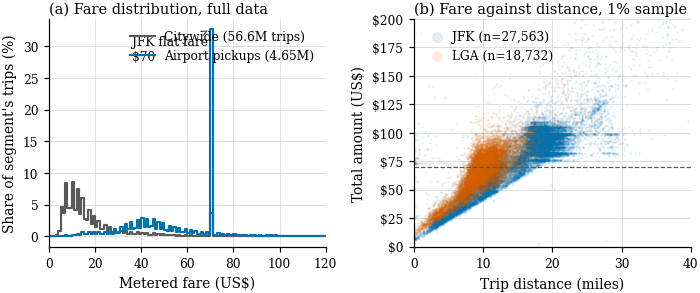

In [9]:
# --- Figure 1 --------------------------------------------------------------
# (a) the full fare distribution, airport against citywide, from the complete
#     value spectrum computed above; (b) the fare-distance relationship, which
#     is the only place in this notebook a sample is used.
BIN_WIDTH = 1.0
FARE_PLOT_MAX = 120.0
DISTANCE_PLOT_MAX = 40.0
TOTAL_PLOT_MAX = 200.0

binned = (
    fare_spectrum[fare_spectrum["fare"] <= FARE_PLOT_MAX]
    .assign(bin=lambda frame: np.floor(frame["fare"] / BIN_WIDTH) * BIN_WIDTH)
    .groupby("bin")[["trips", "airport_trips"]]
    .sum()
)
# Denominators are the full segment totals, not the plotted range, so the two
# curves are shares of all trips and the truncated tail is visible as the
# shortfall rather than hidden by renormalisation.
citywide_share = 100 * binned["trips"] / clean_total
airport_share = 100 * binned["airport_trips"] / airport_total

scatter = (
    trips
    .where(F.col("is_airport"))
    .select("trip_distance", "total_amount", "pulocationid")
    .sample(fraction=SAMPLE_FRACTION, seed=SAMPLE_SEED)
    .toPandas()
)
scatter["airport"] = np.where(scatter["pulocationid"] == JFK_ZONE, "JFK", "LGA")

fig, axes = new_figure(1, 2, height=2.9)

ax = axes[0]
ax.step(binned.index, citywide_share, where="post", color=BASELINE_COLOUR,
        label=f"Citywide ({clean_total / 1e6:.1f}M trips)")
ax.step(binned.index, airport_share, where="post", color=PALETTE["blue"],
        label=f"Airport pickups ({airport_total / 1e6:.2f}M)")
flat_bin = float(np.floor(JFK_FLAT_FARE / BIN_WIDTH) * BIN_WIDTH)
peak = float(airport_share.get(flat_bin, 0.0))
ax.annotate(
    f"JFK flat fare\n${JFK_FLAT_FARE:,.0f}",
    xy=(flat_bin, peak),
    xytext=(flat_bin - 34, peak * 0.85),
    arrowprops={"arrowstyle": "->", "lw": 0.8, "color": PALETTE["grey"]},
    fontsize=8,
)
ax.set_xlim(0, FARE_PLOT_MAX)
ax.set_xlabel("Metered fare (US$)")
ax.set_ylabel("Share of segment's trips (%)")
ax.set_title("(a) Fare distribution, full data")
ax.legend(loc="upper right")

ax = axes[1]
for airport, group in scatter.groupby("airport"):
    ax.scatter(group["trip_distance"], group["total_amount"], s=2, alpha=0.12,
               linewidths=0, color=airport_colour(airport),
               label=f"{airport} (n={len(group):,})")
ax.axhline(JFK_FLAT_FARE, color=PALETTE["grey"], lw=0.8, ls="--")
ax.set_xlim(0, DISTANCE_PLOT_MAX)
ax.set_ylim(0, TOTAL_PLOT_MAX)
ax.set_xlabel("Trip distance (miles)")
ax.set_ylabel("Total amount (US$)")
ax.set_title(f"(b) Fare against distance, {SAMPLE_FRACTION:.0%} sample")
ax.legend(loc="upper left", markerscale=5, handletextpad=0.2)
currency_axis(ax)

fig.tight_layout()
save_figure(fig, "fig01_fare_distribution")

### Step 1e — Nulls, and what was imputed

Three claims the report has to be able to make, in one place:

1. **No trip-level value was imputed.** 2a's policy was to remove what a business rule
   invalidates, retain and flag what is merely extreme, and retain and flag what is
   unrecorded. Nothing was filled in.
2. **Every null in the airport-hour table is structural**, and belongs to a family 2c
   documented — an hour with no trips has no mean fare, the first week has no weekly lag,
   an hour with nothing scheduled has no long-haul share.
3. **The one place values were filled is the weather**, where a gap in a station's record
   was carried forward under a bounded lookback, or resolved from a neighbouring station,
   and every filled hour is flagged.

The audit below re-derives the null counts from the written table and requires each one to
match a documented family. It mirrors 2c's audit deliberately: if a later edit to 2c
introduces an unexplained null, this notebook fails rather than plotting it.

In [10]:
model_table = spark.read.parquet(str(CURATED_DIR / "model_table.parquet"))
assert model_table.count() == EXPECTED_ROWS

null_counts = {
    column: count
    for column, count in model_table.select([
        F.sum(F.col(column).isNull().cast("int")).alias(column)
        for column in model_table.columns
    ]).collect()[0].asDict().items()
    if count
}

# Families, in the order they are tested, mirroring notebook 2c's audit.
LAG_SUFFIXES = ("_lag_1h", "_lag_24h", "_lag_168h", "_same_hour_7d")
EMPTY_HOUR_MEANS = [
    "mean_fare", "median_fare", "mean_total", "mean_distance_mi",
    "mean_duration_min", "mean_passengers", "share_flat_fare",
    "share_flex_fare", "mean_tip_ratio",
]
WEATHER_COLUMNS = [
    "temp_c", "rhum_pct", "prcp_mm", "wspd_kmh", "pres_hpa",
    "is_precip", "is_freezing",
]
NOTHING_SCHEDULED = ["share_longhaul", "share_cancelled", "ewr_share_cancelled"]
DELAY_COLUMNS = [
    "mean_arr_delay_min", "share_delayed_15", "ewr_mean_arr_delay_min",
]
WINDOW_EDGE = ["sched_arrivals_prev_hr", "sched_arrivals_next_hr"]


def null_family(column: str) -> str:
    """Return the documented reason a column contains nulls.

    Args:
        column: Column name from the model table.

    Returns:
        The family label, or ``"UNEXPLAINED"`` if no documented family
        matches, which the assertion below treats as a failure.
    """
    if column.endswith(LAG_SUFFIXES):
        return "no history yet (first week, or first hour of the window)"
    if column in EMPTY_HOUR_MEANS:
        return "statistic of an hour with no pickups"
    if column in WEATHER_COLUMNS:
        return "weather gap beyond the fill limit"
    if column in NOTHING_SCHEDULED:
        return "nothing scheduled to land in the hour"
    if column in DELAY_COLUMNS:
        return "no arrival delay observed in the hour"
    if column in WINDOW_EDGE:
        return "first or last hour of the window"
    if column == "holiday_name":
        return "ordinary (non-holiday) day"
    return "UNEXPLAINED"


null_summary = pd.DataFrame([
    {
        "column": column,
        "nulls": count,
        "pct_of_rows": round(100 * count / EXPECTED_ROWS, 2),
        "family": null_family(column),
    }
    for column, count in sorted(null_counts.items(), key=lambda item: -item[1])
])
assert not (null_summary["family"] == "UNEXPLAINED").any(), (
    "Undocumented nulls: "
    f"{null_summary.loc[null_summary['family'] == 'UNEXPLAINED', 'column'].tolist()}"
)

with open(CURATED_DIR / "shapes_model_table.json") as handle:
    shapes_model = json.load(handle)

print("Null families in the airport-hour table")
print(
    null_summary.groupby("family")
    .agg(columns=("column", "size"), worst_case_rows=("nulls", "max"))
    .sort_values("worst_case_rows", ascending=False)
    .to_string()
)
print("\nThe only imputation performed anywhere in the pipeline:")
print(f"  weather hours carried forward         "
      f"{shapes_model['weather_hours_carried_forward']:,}")
print(f"  weather hours still unobserved        "
      f"{shapes_model['weather_hours_unobserved']:,}")
prcp_filled = shapes_model["precipitation_hours_not_observed_at_site"]
print(f"  precipitation from a neighbour or dry {prcp_filled:,} "
      f"({100 * prcp_filled / EXPECTED_ROWS:.1f}% of airport-hours)")

Null families in the airport-hour table
                                                          columns  worst_case_rows
family                                                                            
ordinary (non-holiday) day                                      1            25104
no history yet (first week, or first hour of the window)       20             5355
no arrival delay observed in the hour                           3             5353
nothing scheduled to land in the hour                           3             5342
statistic of an hour with no pickups                            9             1540
first or last hour of the window                                2                2

The only imputation performed anywhere in the pipeline:
  weather hours carried forward         4
  weather hours still unobserved        0
  precipitation from a neighbour or dry 1,527 (5.8% of airport-hours)


## Step 2 — The distribution of the modelling target

Model 1 predicts `n_pickups`, a count, which points at a Poisson GLM. A Poisson has one
parameter and therefore one strong assumption: the conditional variance equals the
conditional mean. That assumption is testable **before** anything is fitted, and testing it
here is what makes the model choice in notebook 4 a justified decision rather than a default.

The test has to be conditional. The unconditional variance of `n_pickups` is enormous
because 03:00 and 18:00 are different worlds, and quoting it would say nothing about the
model. The dispersion ratio is therefore computed within `(airport, hour-of-day)` cells,
across the 547 days of the window — which is close to what the model actually sees once
hour is in the linear predictor.

If the ratio sits well above 1, the Poisson's point predictions remain usable but its
standard errors are optimistic, and the honest responses are a quasi-Poisson correction or
a negative binomial. Saying so now, and carrying it into notebook 4, is exactly the
"justify your model and list your assumptions" requirement.

In [11]:
hours = model_table.toPandas()
hours["date"] = pd.to_datetime(hours["date"])
assert len(hours) == EXPECTED_ROWS

# Conditional dispersion: variance against mean within (airport, hour) cells,
# each of which holds one observation per day of the window.
cells = (
    hours.groupby(["airport", "hour"])["n_pickups"]
    .agg(mean="mean", variance="var", days="size")
    .reset_index()
)
cells["dispersion"] = cells["variance"] / cells["mean"].where(cells["mean"] > 0)

dispersion_summary = (
    cells.groupby("airport")["dispersion"]
    .agg(median_dispersion="median", min_dispersion="min", max_dispersion="max")
)
overdispersed_cells = int((cells["dispersion"] > 1).sum())

print("Conditional dispersion (variance / mean) within airport-hour cells")
print(dispersion_summary.round(2).to_string())
print(f"\n{overdispersed_cells} of {len(cells)} cells have a ratio above 1")

# Zero-demand hours, and when they happen.
zero_hours = hours[hours["n_pickups"] == 0]
overnight = zero_hours[zero_hours["hour"].between(2, 5)]
print(f"\nAirport-hours with no pickups: {len(zero_hours):,} of {EXPECTED_ROWS:,} "
      f"({100 * len(zero_hours) / EXPECTED_ROWS:.1f}%)")
print(f"  of which 02:00–05:59: {len(overnight):,} "
      f"({100 * len(overnight) / len(zero_hours):.1f}% of them)")
print(zero_hours.groupby("airport").size().to_string())

Conditional dispersion (variance / mean) within airport-hour cells
         median_dispersion  min_dispersion  max_dispersion
airport                                                   
JFK                  12.44            7.56           43.02
LGA                  21.40            1.70           53.86

48 of 48 cells have a ratio above 1

Airport-hours with no pickups: 1,180 of 26,256 (4.5%)
  of which 02:00–05:59: 1,017 (86.2% of them)
airport
JFK      47
LGA    1133


Saved plots/fig02_target_distribution.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig02_target_distribution.png')

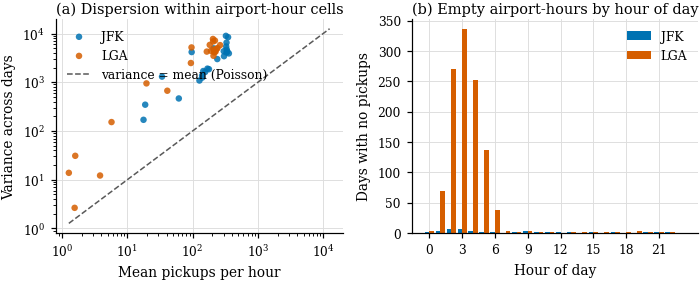

In [12]:
# --- Figure 2 --------------------------------------------------------------
# (a) the Poisson assumption, drawn as variance against mean with the equality
#     line the assumption asserts; (b) where the empty hours are.
fig, axes = new_figure(1, 2, height=2.8)

ax = axes[0]
for airport, group in cells.groupby("airport"):
    ax.scatter(group["mean"], group["variance"], s=18, alpha=0.85,
               color=airport_colour(airport), label=airport, edgecolors="none")
# The equality line is drawn across the range the data actually occupies, so a
# quiet 03:00 cell is not pushed off the axis by a hardcoded lower bound.
limit = max(cells["mean"].max(), cells["variance"].max()) * 1.4
lower = float(cells.loc[cells["mean"] > 0, "mean"].min())
reference = np.array([lower, limit])
ax.plot(reference, reference, color=PALETTE["grey"], lw=1.0, ls="--",
        label="variance = mean (Poisson)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Mean pickups per hour")
ax.set_ylabel("Variance across days")
ax.set_title("(a) Dispersion within airport-hour cells")
ax.legend(loc="upper left")

ax = axes[1]
zero_by_hour = (
    zero_hours.groupby(["hour", "airport"]).size().unstack("airport", fill_value=0)
    .reindex(range(24), fill_value=0)
)
width = 0.42
for offset, airport in zip((-width / 2, width / 2), ARRIVAL_AIRPORTS):
    ax.bar(zero_by_hour.index + offset, zero_by_hour.get(airport, 0), width=width,
           color=airport_colour(airport), label=airport)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Days with no pickups")
ax.set_title("(b) Empty airport-hours by hour of day")
ax.legend()

fig.tight_layout()
save_figure(fig, "fig02_target_distribution")

## Step 3 — Temporal structure: do volume and value peak together?

This is the figure the whole two-model design rests on. If the busiest airport-hours are
also the most valuable ones, a single model of demand would be enough and the advice
collapses to *go when it is busy*. If they diverge — if the hours with the most pickups are
not the hours with the highest average fare — then a driver choosing when to queue faces a
real trade-off, the two models have separate jobs, and the recommendations have something to
say that common sense does not.

Four panels: mean pickups per hour and mean fare per trip, by hour of day and day of week,
for each airport.

The two rows scale differently, on purpose. **Volume is on one shared scale**, because the
two airports are genuinely comparable in trips per hour and the difference in level is
itself a result. **Value is scaled within each airport**, because JFK's flat fare puts its
fare distribution in a range LaGuardia's barely reaches: on a shared scale both panels would
render as flat blocks of colour and the within-airport variation — which is the entire point
of the row — would be invisible. The colour bars carry the ranges, and the report caption
must say the value panels are not on a common scale.

Below the figure the divergence is quantified rather than eyeballed: a rank correlation
across the 168 cells, and the cells where the two ranks disagree most.

Saved plots/fig03_hour_weekday_heatmaps.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig03_hour_weekday_heatmaps.png')

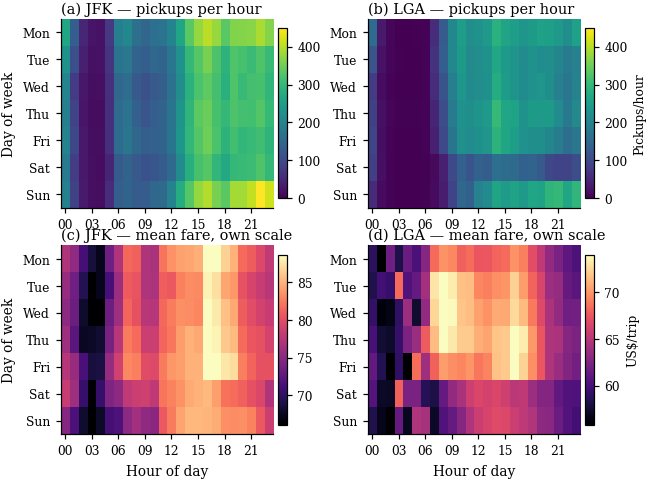

In [13]:
DAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
HOUR_LABELS = [f"{hour:02d}" for hour in range(24)]


def hour_weekday_matrix(frame: pd.DataFrame, value: str) -> np.ndarray:
    """Average a column into a 7 × 24 day-of-week by hour-of-day grid.

    Args:
        frame: Airport-hour rows for a single airport.
        value: Column to average. Nulls are skipped, which is what makes this
            correct for ``mean_total``: an hour with no pickups has no average
            fare, and counting it as zero would report empty hours as cheap
            ones.

    Returns:
        A 7 × 24 array, Monday first, reindexed so that a missing combination
        would appear as NaN rather than shifting the grid.
    """
    grid = frame.pivot_table(
        index="day_of_week", columns="hour", values=value, aggfunc="mean"
    )
    return grid.reindex(index=range(1, 8), columns=range(24)).to_numpy()


volume_grids = {
    code: hour_weekday_matrix(group, "n_pickups")
    for code, group in hours.groupby("airport")
}
value_grids = {
    code: hour_weekday_matrix(group, "mean_total")
    for code, group in hours.groupby("airport")
}

fig, axes = new_figure(2, 2, height=4.9)

# Volume: one scale across both airports, so the levels are comparable.
volume_max = max(np.nanmax(grid) for grid in volume_grids.values())
for column, airport in enumerate(ARRIVAL_AIRPORTS):
    image = heatmap(
        axes[0][column], volume_grids[airport], DAY_LABELS, HOUR_LABELS,
        vmin=0, vmax=volume_max,
        title=f"({'ab'[column]}) {airport} — pickups per hour",
        ylabel="" if column else "Day of week",
    )
    bar = fig.colorbar(image, ax=axes[0][column], shrink=0.9, pad=0.02)
    # Labelled once per row, on the right, so the label cannot collide with
    # the neighbouring panel's tick labels.
    bar.set_label("Pickups/hour" if column else "", size=8)

# Value: scaled within airport. The two fare distributions barely overlap, so a
# shared scale would flatten both panels and hide the variation across cells
# that this row exists to show. Clipped to the 2nd–98th percentile so one
# unusual cell cannot consume the range.
for column, airport in enumerate(ARRIVAL_AIRPORTS):
    grid = value_grids[airport]
    low, high = np.nanpercentile(grid, [2, 98])
    image = heatmap(
        axes[1][column], grid, DAY_LABELS, HOUR_LABELS,
        vmin=low, vmax=high, cmap="magma",
        title=f"({'cd'[column]}) {airport} — mean fare, own scale",
        xlabel="Hour of day", ylabel="" if column else "Day of week",
    )
    bar = fig.colorbar(image, ax=axes[1][column], shrink=0.9, pad=0.02)
    bar.set_label("US$/trip" if column else "", size=8)

save_figure(fig, "fig03_hour_weekday_heatmaps")

In [14]:
def grid_to_long(grid: np.ndarray, airport: str, name: str) -> pd.DataFrame:
    """Reshape a 7 × 24 grid into long form.

    Args:
        grid: Array as returned by :func:`hour_weekday_matrix`.
        airport: Airport code to attach.
        name: Name for the value column.

    Returns:
        A frame with ``day_of_week``, ``hour``, ``airport``, and the value.
    """
    frame = pd.DataFrame(grid, index=range(1, 8), columns=range(24))
    long = frame.stack().reset_index()
    long.columns = ["day_of_week", "hour", name]
    long["airport"] = airport
    return long


cells_long = pd.concat([
    grid_to_long(volume_grids[airport], airport, "mean_pickups").merge(
        grid_to_long(value_grids[airport], airport, "mean_total"),
        on=["day_of_week", "hour", "airport"],
    )
    for airport in ARRIVAL_AIRPORTS
], ignore_index=True)

# Ranked within airport, because the two airports differ in level and the
# question is about the ordering of cells within a driver's own choice set.
cells_long["volume_rank"] = cells_long.groupby("airport")["mean_pickups"].rank(pct=True)
cells_long["value_rank"] = cells_long.groupby("airport")["mean_total"].rank(pct=True)
cells_long["rank_gap"] = cells_long["value_rank"] - cells_long["volume_rank"]

print("Rank correlation between volume and value across the 168 cells")
for airport, group in cells_long.groupby("airport"):
    usable = group.dropna(subset=["mean_pickups", "mean_total"])
    rho, pvalue = stats.spearmanr(usable["mean_pickups"], usable["mean_total"])
    print(f"  {airport}  Spearman rho = {rho:+.3f}   p = {pvalue:.2g}   "
          f"n = {len(usable)} cells")

print("\nHigh value, low volume — the cells the two models disagree about most")
best_gap = cells_long.nlargest(6, "rank_gap").copy()
best_gap["day"] = best_gap["day_of_week"].map(dict(enumerate(DAY_LABELS, start=1)))
print(best_gap[[
    "airport", "day", "hour", "mean_pickups", "mean_total",
    "volume_rank", "value_rank",
]].round(2).to_string(index=False))

Rank correlation between volume and value across the 168 cells
  JFK  Spearman rho = +0.771   p = 2e-34   n = 168 cells
  LGA  Spearman rho = +0.536   p = 7.3e-14   n = 168 cells

High value, low volume — the cells the two models disagree about most
airport day  hour  mean_pickups  mean_total  volume_rank  value_rank
    LGA Sat     3          0.68       68.04         0.01        0.65
    LGA Tue     7         65.03       73.07         0.31        0.95
    LGA Wed     7         56.81       72.51         0.30        0.93
    LGA Thu     8        107.10       74.45         0.38        0.99
    LGA Fri     5          1.56       68.46         0.08        0.70
    LGA Wed     8        117.10       75.18         0.39        1.00


In [15]:
# Holidays. The three regimes are already flagged in the table by 2c, which
# also separates federal holidays from the adjacent travel days around them.
hours["day_type"] = np.select(
    [hours["is_holiday"].astype(bool), hours["is_holiday_adjacent"].astype(bool)],
    ["federal holiday", "adjacent travel day"],
    default="ordinary day",
)

holiday_summary = hours.groupby("day_type").agg(
    days=("date", "nunique"),
    mean_pickups_per_hour=("n_pickups", "mean"),
    mean_fare=("mean_total", "mean"),
)
print(holiday_summary.round(2).to_string())

# The adjacent-day figure is counterintuitive, so it is decomposed rather than
# reported as an average: the flag covers both the busiest travel day of the
# American year and the two deadest evenings in December.
named_days = (
    hours[hours["holiday_name"].notna()]
    .groupby(["holiday_name", "day_type"])["n_pickups"]
    .mean()
    .sort_values()
)
print("\nMean pickups per airport-hour, by named day (quietest first)")
print(named_days.round(1).to_string())

                     days  mean_pickups_per_hour  mean_fare
day_type                                                   
adjacent travel day     6                 155.90      70.04
federal holiday        18                 183.02      70.48
ordinary day          523                 177.27      72.83

Mean pickups per airport-hour, by named day (quietest first)
holiday_name                day_type           
Christmas Eve               adjacent travel day     83.8
Thanksgiving Day            federal holiday         87.9
Christmas Day               federal holiday         99.6
Day after Thanksgiving      adjacent travel day    131.9
Veterans Day                federal holiday        140.7
New Year's Eve              adjacent travel day    151.1
Thanksgiving eve            adjacent travel day    153.4
Day after Christmas         adjacent travel day    163.7
New Year's Day              federal holiday        164.1
Independence Day            federal holiday        168.4
Martin Luther King J

## Step 4 — From flights to pickups

Two questions, and the first one turns a stated limitation of the flight data into an
analytical result.

**How many pickups does an arrival generate?** BTS covers domestic flights only, so the
ratio of pickups to scheduled arrivals is not a behavioural constant — it is a measurement of
how much of each airport's traffic the flight feed can see. A large gap between the two
airports is evidence of JFK's international and long-haul mix, which is precisely what the
`share_longhaul` feature is standing in for.

**At what lag do arrivals predict pickups?** Passengers do not appear in the taxi queue in
the hour their aircraft lands: they deplane, walk, wait at a carousel, and queue. If the
correlation between pickups and arrivals peaks at a positive lag, that delay is real,
measurable, and the empirical justification for `sched_arrivals_prev_hr` being in the
feature set rather than a plausible-sounding guess.

The lag is computed by shifting within airport over the completed hourly grid. That is only
a wall-clock lag because 2a's spine guarantees exactly 24 rows per airport per day with no
gaps — the same argument that licensed the positional lags in 2c.

In [16]:
conversion = hours.groupby("airport").agg(
    pickups=("n_pickups", "sum"),
    sched_arrivals=("sched_arrivals", "sum"),
    mean_share_longhaul=("share_longhaul", "mean"),
)
conversion["pickups_per_arrival"] = (
    conversion["pickups"] / conversion["sched_arrivals"]
)
print("Domestic scheduled arrivals against observed pickups")
print(conversion.round(3).to_string())

ratio = (
    conversion.loc["JFK", "pickups_per_arrival"]
    / conversion.loc["LGA", "pickups_per_arrival"]
)
print(f"\nJFK converts {ratio:.1f}x as many pickups per *domestic* arrival as LGA.")
print("This is a coverage gap, not a demand effect: BTS does not report the "
      "international arrivals that JFK serves and LaGuardia essentially does not.")

Domestic scheduled arrivals against observed pickups
         pickups  sched_arrivals  mean_share_longhaul  pickups_per_arrival
airport                                                                   
JFK      2753043          193143                0.385               14.254
LGA      1900138          243611                0.034                7.800

JFK converts 1.8x as many pickups per *domestic* arrival as LGA.
This is a coverage gap, not a demand effect: BTS does not report the international arrivals that JFK serves and LaGuardia essentially does not.


In [17]:
LAGS = [-2, -1, 0, 1, 2]

ordered = hours.sort_values(["airport", "date", "hour"]).copy()
lag_rows = []
for airport, group in ordered.groupby("airport"):
    for lag in LAGS:
        shifted = group["sched_arrivals"].shift(lag)
        lag_rows.append({
            "airport": airport,
            "lag_hours": lag,
            "correlation": group["n_pickups"].corr(shifted),
        })
lag_table = pd.DataFrame(lag_rows).pivot(
    index="lag_hours", columns="airport", values="correlation"
)
print("Correlation of pickups with scheduled arrivals, by lag")
print("(positive lag = arrivals that landed that many hours earlier)")
print(lag_table.round(3).to_string())

best_lag = {
    airport: int(lag_table[airport].idxmax()) for airport in lag_table.columns
}
print(f"\nPeak correlation at lag: {best_lag}")

# Pickups per scheduled arrival by hour of day, as a ratio of sums rather than
# a mean of ratios: hours with nothing scheduled would otherwise divide by zero
# and hours with one arrival would carry the same weight as hours with forty.
per_hour = (
    hours.groupby(["airport", "hour"])[["n_pickups", "sched_arrivals"]]
    .sum()
    .reset_index()
)
per_hour["pickups_per_arrival"] = (
    per_hour["n_pickups"] / per_hour["sched_arrivals"].where(
        per_hour["sched_arrivals"] > 0
    )
)

Correlation of pickups with scheduled arrivals, by lag
(positive lag = arrivals that landed that many hours earlier)
airport      JFK    LGA
lag_hours              
-2         0.218  0.482
-1         0.483  0.633
 0         0.660  0.801
 1         0.717  0.842
 2         0.646  0.805

Peak correlation at lag: {'JFK': 1, 'LGA': 1}


Saved plots/fig04_flights_to_pickups.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig04_flights_to_pickups.png')

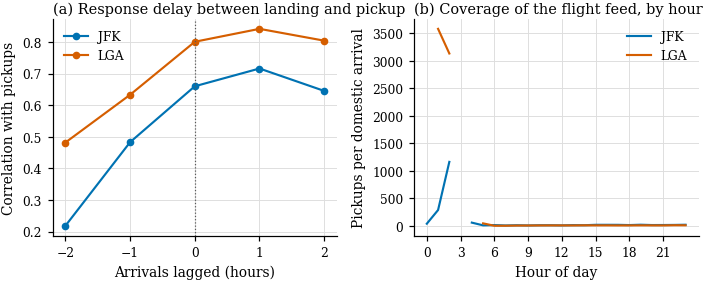

In [18]:
# --- Figure 4 --------------------------------------------------------------
fig, axes = new_figure(1, 2, height=2.8)

ax = axes[0]
for airport in ARRIVAL_AIRPORTS:
    ax.plot(lag_table.index, lag_table[airport], marker="o",
            color=airport_colour(airport), label=airport)
ax.axvline(0, color=PALETTE["grey"], lw=0.8, ls=":")
ax.set_xticks(LAGS)
ax.set_xlabel("Arrivals lagged (hours)")
ax.set_ylabel("Correlation with pickups")
ax.set_title("(a) Response delay between landing and pickup")
ax.legend()

ax = axes[1]
for airport in ARRIVAL_AIRPORTS:
    subset = per_hour[per_hour["airport"] == airport]
    ax.plot(subset["hour"], subset["pickups_per_arrival"],
            color=airport_colour(airport), label=airport)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Pickups per domestic arrival")
ax.set_title("(b) Coverage of the flight feed, by hour")
ax.legend()

fig.tight_layout()
save_figure(fig, "fig04_flights_to_pickups")

## Step 5 — Weather, matched on hour of day

Rain is not distributed evenly across the clock, and demand varies enormously across the
clock, so a naive comparison of wet hours against dry hours would mostly measure **when** it
rained. Every comparison below is therefore made **within** an `(airport, hour-of-day)` cell
and then aggregated across cells, which removes the hour-of-day confound by construction.

Two prior expectations are worth stating before the numbers, so that the result is a test
rather than a story fitted afterwards:

- The effect on **demand** should be weak. An arriving passenger with luggage needs to get
  home whether or not it is raining; unlike a discretionary Manhattan street hail, airport
  demand is close to inelastic in weather.
- Any effect on **value** is more plausible than an effect on volume, through congestion:
  the same trip takes longer, and time-based metered charges accrue.

The study window also coincides with New York's record snow drought, so freezing hours are
rare and any snow effect here is weakly identified. That is reported as a limitation, with
the count, rather than glossed.

If the effect is genuinely small, that is a finding and the report says so. The
specification awards marks for a visualisation that establishes there is nothing interesting
in a direction — provided the reason is discussed rather than the plot abandoned.

In [19]:
observed = hours[~hours["weather_missing"].astype(bool)].copy()
observed["is_precip"] = observed["is_precip"].fillna(False).astype(bool)
observed["is_freezing"] = observed["is_freezing"].fillna(False).astype(bool)
print(f"{len(observed):,} of {EXPECTED_ROWS:,} airport-hours have observed weather")

cell_stats = (
    observed.groupby(["airport", "hour", "is_precip"])
    .agg(
        mean_pickups=("n_pickups", "mean"),
        mean_fare=("mean_total", "mean"),
        cell_hours=("n_pickups", "size"),
    )
    .reset_index()
)

wet = cell_stats[cell_stats["is_precip"]].set_index(["airport", "hour"])
dry = cell_stats[~cell_stats["is_precip"]].set_index(["airport", "hour"])
matched = wet.join(dry, lsuffix="_wet", rsuffix="_dry", how="inner")
matched["delta_pickups"] = matched["mean_pickups_wet"] - matched["mean_pickups_dry"]
matched["pct_change_pickups"] = (
    100 * matched["delta_pickups"] / matched["mean_pickups_dry"]
)
matched["delta_fare"] = matched["mean_fare_wet"] - matched["mean_fare_dry"]

print("\nWet minus dry, matched within (airport, hour-of-day) cells")
for airport, group in matched.groupby(level="airport"):
    weighted_pickups = np.average(
        group["delta_pickups"], weights=group["cell_hours_wet"]
    )
    weighted_fare = np.average(group["delta_fare"], weights=group["cell_hours_wet"])
    weighted_pct = np.average(
        group["pct_change_pickups"], weights=group["cell_hours_wet"]
    )
    test = stats.ttest_1samp(group["delta_pickups"], 0.0)
    print(f"  {airport}  wet hours = {int(group['cell_hours_wet'].sum()):,}")
    print(f"        pickups  {weighted_pickups:+.1f} per hour "
          f"({weighted_pct:+.1f}%), paired t = {test.statistic:+.2f}, "
          f"p = {test.pvalue:.3f}")
    print(f"        fare     ${weighted_fare:+.2f} per trip")

# Freezing precipitation, reported with its own count so the report can state
# how weakly it is identified rather than implying an effect was measured.
freezing = observed[observed["is_freezing"]]
print(f"\nFreezing precipitation: {len(freezing):,} airport-hours "
      f"({100 * len(freezing) / len(observed):.2f}% of observed hours)")
if len(freezing):
    print(f"  mean pickups in those hours: {freezing['n_pickups'].mean():.1f}")
    print(f"  mean pickups in all hours:   {observed['n_pickups'].mean():.1f}")

26,256 of 26,256 airport-hours have observed weather

Wet minus dry, matched within (airport, hour-of-day) cells
  JFK  wet hours = 1,354
        pickups  -4.1 per hour (+3.1%), paired t = -0.99, p = 0.334
        fare     $+0.02 per trip
  LGA  wet hours = 1,402
        pickups  -10.1 per hour (+25.3%), paired t = -2.39, p = 0.025
        fare     $+0.36 per trip

Freezing precipitation: 84 airport-hours (0.32% of observed hours)
  mean pickups in those hours: 122.8
  mean pickups in all hours:   177.2


Wettest day in the window: 2023-09-29 (6.6 mm/hour averaged across the day)
  pickups that day      9,717
  seven-day norm        5,520
  difference            +76.0%
Saved plots/fig05_weather.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig05_weather.png')

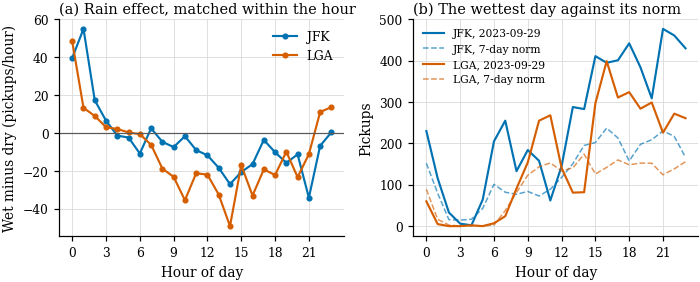

In [20]:
# The wettest day in the window, as a case study. `pickups_same_hour_7d` is the
# trailing mean of the same hour over the previous seven days, so it is the
# natural counterfactual: what that hour normally looks like.
daily_rain = hours.groupby("date")["prcp_mm"].mean()
storm_date = daily_rain.idxmax()
storm = hours[hours["date"] == storm_date].sort_values(["airport", "hour"])

storm_pickups = int(storm["n_pickups"].sum())
storm_normal = float(storm["pickups_same_hour_7d"].sum())
print(f"Wettest day in the window: {storm_date.date()} "
      f"({daily_rain.max():.1f} mm/hour averaged across the day)")
print(f"  pickups that day      {storm_pickups:,}")
print(f"  seven-day norm        {storm_normal:,.0f}")
print(f"  difference            {100 * (storm_pickups / storm_normal - 1):+.1f}%")

# --- Figure 5 --------------------------------------------------------------
fig, axes = new_figure(1, 2, height=2.8)

ax = axes[0]
for airport in ARRIVAL_AIRPORTS:
    group = matched.xs(airport, level="airport")
    ax.plot(group.index, group["delta_pickups"], marker="o", markersize=3,
            color=airport_colour(airport), label=airport)
ax.axhline(0, color=PALETTE["grey"], lw=0.8)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Wet minus dry (pickups/hour)")
ax.set_title("(a) Rain effect, matched within the hour")
ax.legend()

ax = axes[1]
for airport in ARRIVAL_AIRPORTS:
    group = storm[storm["airport"] == airport]
    ax.plot(group["hour"], group["n_pickups"], color=airport_colour(airport),
            label=f"{airport}, {storm_date.date()}")
    ax.plot(group["hour"], group["pickups_same_hour_7d"], ls="--", lw=1.0,
            color=airport_colour(airport), alpha=0.65,
            label=f"{airport}, 7-day norm")
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Pickups")
ax.set_title("(b) The wettest day against its norm")
ax.legend(fontsize=7)

fig.tight_layout()
save_figure(fig, "fig05_weather")

## Step 6 — Geospatial: where the money goes

Pickups occur in two zones, so the informative map is of **drop-offs from airport pickups**.
Four panels: the drop-off distribution for each airport separately, the average fare by
drop-off zone, and how the distribution shifts between day and night.

Three implementation points, each of which is a place this step commonly goes wrong:

- **Aggregate in Spark, plot in pandas.** The grouping runs over the 4.65M airport trips and
  returns at most 263 zones × 2 airports × 2 periods. Nothing derived from the 56.6M-row
  frame is brought to the driver before it has been grouped down.
- **The CRS.** The TLC shapefile is published in EPSG:2263 — the New York State Plane, in
  feet. Plotted as-is against anything in degrees, or measured for area, it is wrong. It is
  converted to EPSG:4326 before use, and the CRS is printed before and after so the
  conversion is visible rather than assumed.
- **Zones 264 and 265** are "Unknown" and "Outside of NYC / N.A.". They have no geometry in
  the shapefile, so they cannot be mapped; their share of drop-offs is computed and reported
  in the caption instead of being silently dropped.

In [21]:
airport_trips = (
    trips
    .where(F.col("is_airport"))
    .withColumn(
        "airport",
        F.when(F.col("pulocationid") == JFK_ZONE, F.lit("JFK")).otherwise(F.lit("LGA")),
    )
    .withColumn("pickup_hour", F.hour("tpep_pickup_datetime"))
    .withColumn(
        "is_night",
        (F.col("pickup_hour") >= NIGHT_START_HOUR)
        | (F.col("pickup_hour") < NIGHT_END_HOUR),
    )
)

# 263 zones × 2 airports × 2 periods at most. Sums are carried rather than
# means so that any later regrouping stays exact.
dropoffs = (
    airport_trips
    .groupBy("airport", "dolocationid", "is_night")
    .agg(
        F.count("*").alias("trips"),
        F.sum("total_amount").alias("sum_total"),
        F.sum("trip_distance").alias("sum_distance_mi"),
        F.sum(F.col("trip_duration_s") / 60.0).alias("sum_duration_min"),
    )
    .toPandas()
)
dropoffs["is_night"] = dropoffs["is_night"].astype(bool)
assert int(dropoffs["trips"].sum()) == airport_total, (
    "The drop-off aggregation lost or duplicated trips"
)

# Citywide originating volume per zone, over the full cleaned dataset. This is
# the re-hail proxy used below: how often a taxi is hailed in the zone the
# airport trip ends in.
zone_supply = (
    trips
    .groupBy("pulocationid")
    .agg(F.count("*").alias("citywide_pickups"))
    .toPandas()
    .rename(columns={"pulocationid": "dolocationid"})
)
zone_supply["pickups_per_hour"] = zone_supply["citywide_pickups"] / WINDOW_HOURS

print(f"{dropoffs['dolocationid'].nunique()} distinct drop-off zones across "
      f"{airport_total:,} airport pickups")

261 distinct drop-off zones across 4,653,181 airport pickups


In [1]:
by_zone = (
    dropoffs.groupby("dolocationid")
    .agg(
        trips=("trips", "sum"),
        sum_total=("sum_total", "sum"),
        sum_distance_mi=("sum_distance_mi", "sum"),
        sum_duration_min=("sum_duration_min", "sum"),
    )
    .reset_index()
)
by_zone["mean_total"] = by_zone["sum_total"] / by_zone["trips"]
by_zone["mean_distance_mi"] = by_zone["sum_distance_mi"] / by_zone["trips"]
by_zone["mean_duration_min"] = by_zone["sum_duration_min"] / by_zone["trips"]
by_zone["share_pct"] = 100 * by_zone["trips"] / by_zone["trips"].sum()

unknown_share = float(
    by_zone.loc[by_zone["dolocationid"].isin(UNKNOWN_ZONES), "share_pct"].sum()
)
print(f"Drop-offs in zones 264/265 (unknown, or outside NYC): "
      f"{unknown_share:.2f}% of airport trips — quoted in the figure caption, "
      "not mapped")

# Share within each airport, so the two panels are comparable despite JFK
# generating 45% more trips than LaGuardia.
per_airport = dropoffs.groupby(["airport", "dolocationid"])["trips"].sum().reset_index()
per_airport["share_pct"] = (
    100 * per_airport["trips"]
    / per_airport.groupby("airport")["trips"].transform("sum")
)
airport_share = {
    airport: group.set_index("dolocationid")["share_pct"]
    for airport, group in per_airport.groupby("airport")
}

# Night against day, as a difference of shares in percentage points. Shares
# rather than counts, because there are simply fewer trips at night and a raw
# difference would map that instead of the change in destination mix.
by_period = (
    dropoffs.groupby(["dolocationid", "is_night"])["trips"].sum()
    .unstack("is_night")
    .reindex(columns=[False, True])
    .fillna(0)
    .rename(columns={False: "day_trips", True: "night_trips"})
)
by_period["night_minus_day_pp"] = (
    100 * by_period["night_trips"] / by_period["night_trips"].sum()
    - 100 * by_period["day_trips"] / by_period["day_trips"].sum()
)

zones_geo = gpd.read_file(LANDING_TLC_DIR / "taxi_zones" / "taxi_zones.shp")
print(f"\nShapefile CRS as published: {zones_geo.crs}")
zones_geo = zones_geo.to_crs(epsg=4326)
print(f"Reprojected to:             {zones_geo.crs}")

zones_geo = zones_geo.rename(
    columns={"LocationID": "dolocationid", "zone": "zone_name"}
)
assert {"dolocationid", "zone_name", "borough"} <= set(zones_geo.columns), (
    f"Unexpected shapefile schema: {list(zones_geo.columns)}"
)
geo = zones_geo.merge(by_zone, on="dolocationid", how="left")
geo["jfk_share_pct"] = geo["dolocationid"].map(airport_share["JFK"])
geo["lga_share_pct"] = geo["dolocationid"].map(airport_share["LGA"])
geo["night_minus_day_pp"] = geo["dolocationid"].map(by_period["night_minus_day_pp"])

# A zone with no trips is not a zone with a zero share on a log scale, and a
# mean fare over a handful of trips is noise. Both become NaN and are drawn in
# the "no data" grey rather than misrepresented.
MIN_ZONE_TRIPS = 500
for column in ("jfk_share_pct", "lga_share_pct"):
    geo[column] = geo[column].replace(0, np.nan)
geo["mean_total_reported"] = geo["mean_total"].where(geo["trips"] >= MIN_ZONE_TRIPS)

print(f"{int(geo['trips'].notna().sum())} of {len(geo)} mapped zones received at "
      f"least one airport trip; {int((geo['trips'] >= MIN_ZONE_TRIPS).sum())} "
      f"received at least {MIN_ZONE_TRIPS:,}")

NameError: name 'dropoffs' is not defined

In [ ]:
# --- Figure 6 --------------------------------------------------------------
share_values = pd.concat([geo["jfk_share_pct"], geo["lga_share_pct"]]).dropna()
share_norm = LogNorm(vmin=max(share_values.min(), 0.005), vmax=share_values.max())

fare_values = geo["mean_total_reported"].dropna()
fare_norm = Normalize(vmin=fare_values.quantile(0.02), vmax=fare_values.quantile(0.98))

# Clipped at the 98th percentile of magnitude so that one tiny zone cannot
# consume the whole diverging scale.
spread = float(np.nanpercentile(np.abs(geo["night_minus_day_pp"]), 98))
spread = max(spread, 0.05)   # TwoSlopeNorm requires vmin < vcenter < vmax
diff_norm = TwoSlopeNorm(vmin=-spread, vcenter=0.0, vmax=spread)

PANELS = [
    ("jfk_share_pct", "(a) JFK — drop-off share",
     share_norm, SEQUENTIAL_CMAP, "% of the airport's trips (log)"),
    ("lga_share_pct", "(b) LaGuardia — drop-off share",
     share_norm, SEQUENTIAL_CMAP, "% of the airport's trips (log)"),
    ("mean_total_reported", "(c) Mean fare by drop-off zone",
     fare_norm, "magma", "Mean total amount (US$)"),
    ("night_minus_day_pp", "(d) Night minus day",
     diff_norm, DIVERGING_CMAP, "Percentage points"),
]

fig, axes = new_figure(2, 2, height=6.6)
bounds = geo.total_bounds

for ax, (column, title, norm, cmap, label) in zip(axes.ravel(), PANELS):
    geo.plot(
        column=column, ax=ax, cmap=cmap, norm=norm,
        linewidth=0.15, edgecolor="white", legend=True,
        legend_kwds={"shrink": 0.62, "label": label},
        missing_kwds={
            "color": MISSING_COLOUR, "edgecolor": "white", "linewidth": 0.15,
        },
    )
    ax.set_title(title)
    ax.set_axis_off()
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])

# `tight_layout` is not used here: each panel holds a fixed-aspect map, so it
# would pad around the whitespace rather than remove it.
fig.subplots_adjust(wspace=0.02, hspace=0.06)
save_figure(fig, "fig06_dropoff_geography")

### Step 6a — Why the drop-off distribution decides what a queue is worth

A fare is not revenue per hour. The hour a driver spends on an airport trip is the trip
itself **plus** whatever happens at the other end, and that depends on where the trip ends:

- A drop-off in Midtown lands the driver in the densest street-hail market in the city. The
  next fare is minutes away.
- A drop-off in deep Brooklyn or eastern Queens lands them somewhere with a fraction of that
  hail rate. The realistic next move is a long empty drive back — an unpaid leg that belongs
  in the arithmetic of the trip that caused it.

So the value of an airport queue is a property of the **distribution of destinations** it
produces, not of its average fare. The table and figure below put the three quantities that
decide it side by side for the largest drop-off zones: what the trip pays, how long it takes,
and how readily the driver can re-hail where it ends — proxied by that zone's own citywide
pickup rate, computed over all 56.6M cleaned trips.

`revenue_per_engaged_hour` is deliberately an optimistic bound: it counts only the metered
leg, and so overstates every zone. It overstates the low-hail zones **most**, which is the
point — even before the empty return is priced in, the ranking already moves.

In [ ]:
zone_table = (
    by_zone[~by_zone["dolocationid"].isin(UNKNOWN_ZONES)]
    .merge(
        zones_geo[["dolocationid", "zone_name", "borough"]],
        on="dolocationid", how="left",
    )
    .merge(
        zone_supply[["dolocationid", "pickups_per_hour"]],
        on="dolocationid", how="left",
    )
)
zone_table["revenue_per_engaged_hour"] = (
    zone_table["mean_total"] / (zone_table["mean_duration_min"] / 60.0)
)

top_zones = zone_table.nlargest(12, "trips")
print("Largest drop-off zones for airport pickups")
print(top_zones[[
    "zone_name", "borough", "share_pct", "mean_total", "mean_duration_min",
    "pickups_per_hour", "revenue_per_engaged_hour",
]].round(2).to_string(index=False))

borough_mix = (
    zone_table.groupby("borough")
    .agg(share_pct=("share_pct", "sum"), mean_total=("mean_total", "mean"))
    .sort_values("share_pct", ascending=False)
)
print("\nDrop-off borough mix")
print(borough_mix.round(2).to_string())

In [ ]:
# --- Figure 7 --------------------------------------------------------------
BOROUGH_COLOURS = {
    "Manhattan": PALETTE["blue"],
    "Queens": PALETTE["vermillion"],
    "Brooklyn": PALETTE["green"],
    "Bronx": PALETTE["purple"],
    "Staten Island": PALETTE["orange"],
    "EWR": PALETTE["sky"],
}

plotted = zone_table[
    (zone_table["trips"] >= MIN_ZONE_TRIPS)
    & zone_table["pickups_per_hour"].notna()
].copy()

fig, ax = new_figure(height=3.4)
for borough, group in plotted.groupby("borough"):
    ax.scatter(
        group["pickups_per_hour"], group["mean_total"],
        s=12 + 90 * group["share_pct"] / plotted["share_pct"].max(),
        color=BOROUGH_COLOURS.get(borough, PALETTE["grey"]),
        alpha=0.75, edgecolors="white", linewidths=0.4, label=borough,
    )

for row in plotted.nlargest(5, "trips").itertuples():
    ax.annotate(
        row.zone_name, xy=(row.pickups_per_hour, row.mean_total),
        xytext=(4, 4), textcoords="offset points", fontsize=7,
        color=PALETTE["grey"],
    )

ax.set_xscale("log")
ax.set_xlabel("Re-hail opportunity in the drop-off zone "
              "(citywide pickups per hour, log scale)")
ax.set_ylabel("Mean fare of the airport trip")
# The qualifiers belong in the report caption, not in a title that would run
# past the text width.
ax.set_title("Fare against the chance of a return fare, by drop-off zone")
print(f"Caption: zones with at least {MIN_ZONE_TRIPS:,} airport drop-offs; "
      "marker area is proportional to the zone's share of airport trips; "
      "re-hail rate is the zone's own citywide pickups per hour over the "
      "study window.")
currency_axis(ax)
ax.legend(loc="upper left", ncol=2, fontsize=7)

fig.tight_layout()
save_figure(fig, "fig07_rehail_tradeoff")

## Step 7 — What carries into the modelling notebook

Written as a file rather than left in an output cell, so that notebook 4 and the report both
read the same numbers.

The findings that change what notebook 4 does:

1. **The target is overdispersed within airport-hour cells.** A Poisson GLM stays the right
   first model — the response is a count, and the log link gives coefficients a driver's
   advisor can read as percentages — but its standard errors need a quasi-Poisson correction,
   or a negative binomial as the contrasting count model. This has to be stated as an
   assumption check that was performed and acted on, not discovered afterwards.
2. **Volume and value do not peak in the same cells.** That is the empirical warrant for the
   two-model design, and the rank gaps identified in Step 3 are the specific hours the
   recommendations should point at.
3. **Arrivals lead pickups.** The lag with the peak correlation is the one the feature set
   should carry, and it was chosen from the data rather than assumed.
4. **Weather is a weak effect on volume.** Do not expect the weather block to carry the
   model; report its coefficient honestly and explain the inelasticity rather than hunting
   for a specification that makes it significant.
5. **Value has geography.** A model of `mean_total` is implicitly a model of where the trips
   go, so the drop-off distribution is the mechanism behind Model 2 and the bridge from the
   model output to the recommendations.

In [ ]:
findings = {
    "distributions": {
        "cleaned_trips": int(clean_total),
        "airport_pickups": int(airport_total),
        "modal_jfk_fare": modal_fare,
        "jfk_trips_at_flat_fare": int(trips_at_flat),
        "airport_fare_upper_fence": round(airport_fare_fence, 2),
        "airport_trips_above_fare_fence": int(extreme_total),
        "airport_pct_above_fare_fence": round(
            100 * extreme_total / airport_total, 3
        ),
    },
    "target": {
        "median_dispersion_by_airport": {
            airport: round(float(value), 2)
            for airport, value in dispersion_summary["median_dispersion"].items()
        },
        "cells_overdispersed": overdispersed_cells,
        "cells_total": int(len(cells)),
        "zero_pickup_hours": int(len(zero_hours)),
        "zero_pickup_hours_overnight_pct": round(
            100 * len(overnight) / len(zero_hours), 1
        ),
    },
    "temporal": {
        "volume_value_spearman": {
            airport: round(
                float(stats.spearmanr(
                    group.dropna(subset=["mean_pickups", "mean_total"])["mean_pickups"],
                    group.dropna(subset=["mean_pickups", "mean_total"])["mean_total"],
                ).statistic),
                3,
            )
            for airport, group in cells_long.groupby("airport")
        },
        "mean_pickups_by_day_type": {
            str(key): round(float(value), 1)
            for key, value in holiday_summary["mean_pickups_per_hour"].items()
        },
    },
    "flights": {
        "pickups_per_domestic_arrival": {
            airport: round(float(value), 2)
            for airport, value in conversion["pickups_per_arrival"].items()
        },
        "peak_correlation_lag_hours": best_lag,
    },
    "weather": {
        "observed_hours": int(len(observed)),
        "freezing_hours": int(len(freezing)),
        "wettest_day": str(storm_date.date()),
        "wettest_day_vs_norm_pct": round(
            100 * (storm_pickups / storm_normal - 1), 1
        ),
    },
    "geospatial": {
        "dropoff_zones_used": int(dropoffs["dolocationid"].nunique()),
        "unknown_zone_share_pct": round(unknown_share, 2),
        "top_dropoff_zone": str(top_zones.iloc[0]["zone_name"]),
        "top_dropoff_zone_share_pct": round(
            float(top_zones.iloc[0]["share_pct"]), 2
        ),
        "manhattan_share_pct": round(
            float(borough_mix.loc["Manhattan", "share_pct"]), 2
        ),
    },
}

with open(CURATED_DIR / "analysis_findings.json", "w") as handle:
    json.dump(findings, handle, indent=2)

print(f"Written to {CURATED_DIR / 'analysis_findings.json'}")
print("\nFigures produced:")
for path in sorted(PLOTS_DIR.glob("fig*.png")):
    print(f"  {path.name}")

In [ ]:
spark.stop()

## What to carry into the report

**Analysis and geospatial section.** Lead with the divergence between volume and value from
Figure 3 — it is the finding that justifies everything after it. Then Figure 6, because the
drop-off geography is what turns "this hour pays more" into advice a driver can act on.
Figures 1, 2, 4, and 5 are supporting evidence and should be quoted in a sentence each
rather than walked through.

**Say the outlier policy out loud, once.** Records that violated a documented business rule
were removed in 2a; records that are merely extreme were retained, and Step 1b and 1c name
what they are. A marker checking for the required outlier analysis should find the fence,
the count, the share, and the identification of the tail as genuine long-haul rate codes in
one paragraph.

**State the sampling policy in the caption of Figure 1(b)**, with the fraction and the seed,
and state once in the preprocessing or analysis text that every other result uses the full
distribution. This is an explicit requirement of the specification and it costs one sentence.

**The flat-fare mass point is a real distributional finding**, not a curiosity. It explains
why the airport fare distribution is bimodal where the citywide one is not, it is the
mechanism that decouples JFK revenue from distance, and it constrains what Model 2 can be
asked to do.

**Report the weather result honestly.** If the effect on volume is small, say so, explain
the inelasticity of arriving passengers, and note the snow drought as a limitation on
identification. A negative result that is explained is worth more than a marginal one that
is oversold.

**Cite the figures by number in the prose** — "From Figure 3 we can see ... therefore ...
perhaps because ..." — rather than letting them sit unreferenced.

**Next:** notebook 4 reads `model_table.parquet` and `model_table_roles.json`, fits the
Poisson GLM and the gradient-boosted trees against the seasonal-naive benchmark from 2c, and
combines them into expected revenue per airport-hour.